In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
from src.data_manager import DataManager

group_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/em/fibsem-uint8/' 
seg_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/labels/mito_seg/'

# Configuration
em_resolution = 's1' # 8x8x8 nm voxels
segmentation_resolution = 's0' # 8x8x8 nm voxels

data_manager = DataManager(group_url, seg_url, em_resolution, segmentation_resolution, 'jrc_mus-liver')


/opt/homebrew/Caskroom/miniconda/base/envs/mito-mia/lib/python3.12/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))
/opt/homebrew/Caskroom/miniconda/base/envs/mito-mia/lib/python3.12/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))


In [4]:
data_manager.em_data.view_groups()

(
    ('s0', <zarr.core.Array '/em/fibsem-uint8/s0' (8932, 12728, 12747) uint8 read-only>),
    ('s1', <zarr.core.Array '/em/fibsem-uint8/s1' (4466, 6364, 6373) uint8 read-only>),
    ('s10', <zarr.core.Array '/em/fibsem-uint8/s10' (8, 12, 12) uint8 read-only>),
    ('s11', <zarr.core.Array '/em/fibsem-uint8/s11' (4, 6, 6) uint8 read-only>),
    ('s12', <zarr.core.Array '/em/fibsem-uint8/s12' (2, 3, 3) uint8 read-only>),
    ('s2', <zarr.core.Array '/em/fibsem-uint8/s2' (2233, 3182, 3186) uint8 read-only>),
    ('s3', <zarr.core.Array '/em/fibsem-uint8/s3' (1116, 1591, 1593) uint8 read-only>),
    ('s4', <zarr.core.Array '/em/fibsem-uint8/s4' (558, 795, 796) uint8 read-only>),
    ('s5', <zarr.core.Array '/em/fibsem-uint8/s5' (279, 397, 398) uint8 read-only>),
    ('s6', <zarr.core.Array '/em/fibsem-uint8/s6' (139, 198, 199) uint8 read-only>),
    ('s7', <zarr.core.Array '/em/fibsem-uint8/s7' (69, 99, 99) uint8 read-only>),
    ('s8', <zarr.core.Array '/em/fibsem-uint8/s8' (34, 49, 49) uint8 read-only>),
    ('s9', <zarr.core.Array '/em/fibsem-uint8/s9' (17, 24, 24) uint8 read-only>)
)

In [5]:
data_manager.segmentation_data.view_groups()

(
    ('s0', <zarr.core.Array '/labels/mito_seg/s0' (4466, 6364, 6372) uint32 read-only>),
    ('s1', <zarr.core.Array '/labels/mito_seg/s1' (2233, 3182, 3186) uint32 read-only>),
    ('s2', <zarr.core.Array '/labels/mito_seg/s2' (1116, 1591, 1593) uint32 read-only>),
    ('s3', <zarr.core.Array '/labels/mito_seg/s3' (558, 795, 796) uint32 read-only>),
    ('s4', <zarr.core.Array '/labels/mito_seg/s4' (279, 397, 398) uint32 read-only>),
    ('s5', <zarr.core.Array '/labels/mito_seg/s5' (139, 198, 199) uint32 read-only>),
    ('s6', <zarr.core.Array '/labels/mito_seg/s6' (69, 99, 99) uint32 read-only>)
)

In [6]:
from src.slice_generator import SliceGenerator

# 16 nm per px, 128 px patch sizes capture ~31-62 px mitochondria (see readme.md)
patch_size = 512

# Z-step, 128 px (2 microns) per plane
z_step = 128

# Inset to handle microscopy edge effects from the slices
inset = 128

slicer = SliceGenerator(data_manager, patch_size, z_step, inset)
slices = slicer.generate()

In [10]:
from src.model import load_vitb16_model, load_vits16_model, load_vith16plus_model

vits_model = load_vits16_model() # smallest
# vitb_model = load_vitb16_model() # baseline, medium
# vithplus_model = load_vith16plus_model() # largest model

model = vits_model


In [11]:
from src.embeddings import EmbeddingsManager

embeddings_manager = EmbeddingsManager(data_manager, model)

In [12]:
import numpy as np

# Select 200 random slices to examine for mitochondria
num_slices_search = 10
np.random.seed(123)
slice_indices = np.random.choice(len(slices), size=num_slices_search)
slices_subset = [slices[i] for i in slice_indices]

In [13]:
from src.mito_slice_manager import MitoSliceManager

# Build catalog of mitochondria to slices (filtering out
# slices without mitochondria)
mito_slice_manager = MitoSliceManager(data_manager, slices_subset)
mito_catalog = mito_slice_manager.build()
mito_ids = mito_slice_manager.mito_ids()
slices_with_mito = mito_slice_manager.best_slices()


0/10 - 00:00:00.678
9/10 - 00:00:04.684


In [14]:
print(f"Of the {len(slices)} total slices, ")
print(f"   we examine {len(slices_with_mito)} ({len(slices_with_mito)/len(slices)*100:.1f}%) with {len(mito_ids)} mitochondria")

Of the 19008 total slices, 
   we examine 9 (0.0%) with 158 mitochondria


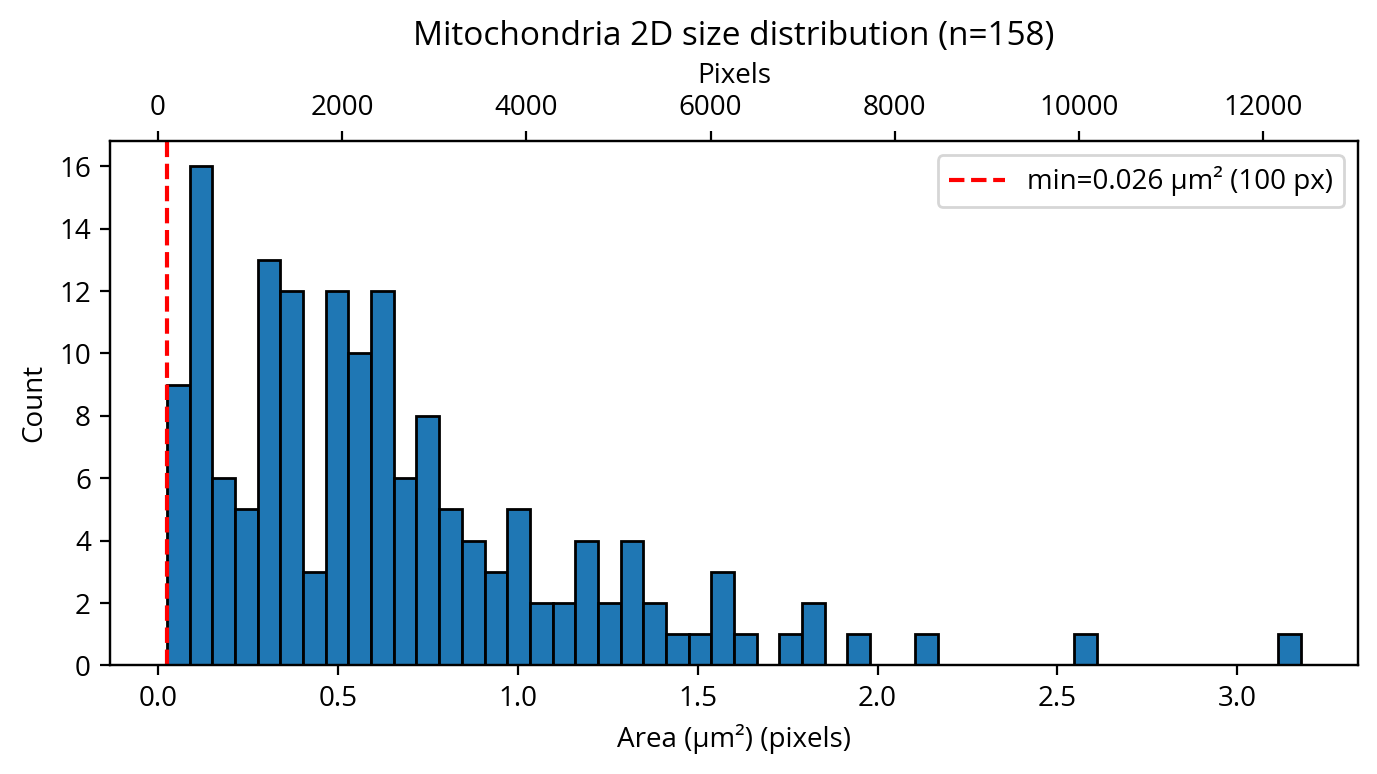

In [15]:
mito_slice_manager.plot_size_distribution()

In [65]:
all_patch_embeddings = embeddings_manager.compute_patch_embeddings(slices_subset)

0/10 - 00:00:01.596


In [29]:
mito_entry

MitoEntry(id=11011, slice_index=0, num_pixels=1489

In [17]:
mito_id = mito_ids[0]
mito_entry = mito_catalog[mito_id]
slice_index = mito_entry.slice_index

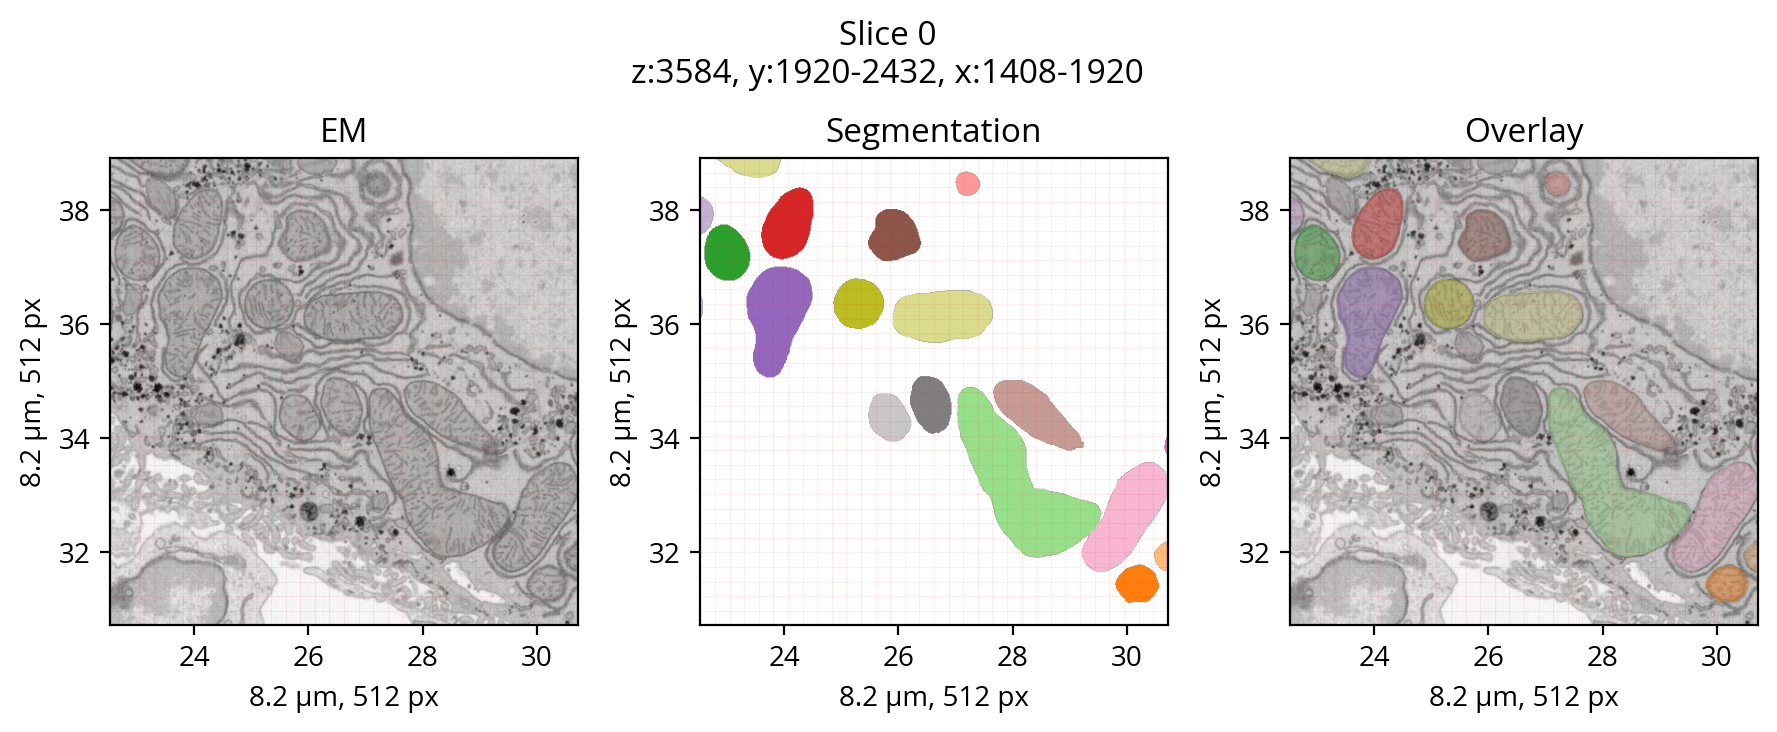

In [36]:
from src.visualizer import Visualizer
vis = Visualizer(data_manager)

slc = slices_subset[slice_index]

z_index_to_plot = slc.z.start
vis.plot_segmentation_example(slc, z_index=z_index_to_plot, title=f"Slice {slice_index}\n"
    f"z:{slc.z.start}, y:{slc.y.start}-{slc.y.stop}, x:{slc.x.start}-{slc.x.stop}")


In [44]:
from src.slice_analyzer import SliceAnalyzer

patch_embeddings = embeddings_manager.compute_patch_embedding(slc)


In [70]:
slice_analyzer = SliceAnalyzer(data_manager)

In [72]:
# _, reference_vector = slice_analyzer.select_mitochondria(mito_id)

In [71]:
# distances = slice_analyzer.compute_distance_map()
# slice_analyzer.plot()


In [80]:
from src.timer import Timer

timer = Timer()
# Compute the per-mitochondria embeddings
all_mito_vectors = {}
last_slice_index = None

for i, mito_id in enumerate(mito_ids):
    
    mito_entry = mito_catalog[mito_id]

    if slice_index != mito_entry.slice_index:
        slc = slices_subset[mito_entry.slice_index]
        patch_embeddings = all_patch_embeddings[mito_entry.slice_index]
        slice_analyzer.set_slice(slc)
        slice_analyzer.set_embeddings(patch_embeddings, is_dense=False)

    slice_analyzer.select_mitochondria(mito_id)
    all_mito_vectors[mito_id] = slice_analyzer.reference_vector

    if i % 10 == 0:
        timer.print_time(f"{i}/{len(mito_ids)}")


0/158 - 00:00:00.280
10/158 - 00:00:01.531
20/158 - 00:00:09.341
30/158 - 00:00:23.221
40/158 - 00:00:38.077
50/158 - 00:00:51.812
60/158 - 00:01:07.251
70/158 - 00:01:21.812
80/158 - 00:01:36.799
90/158 - 00:01:52.052
100/158 - 00:02:08.522
110/158 - 00:02:22.703
120/158 - 00:02:37.185
130/158 - 00:02:51.542
140/158 - 00:03:05.996
150/158 - 00:03:19.518


In [78]:
slice_analyzer.reference_vector.shape

(384,)

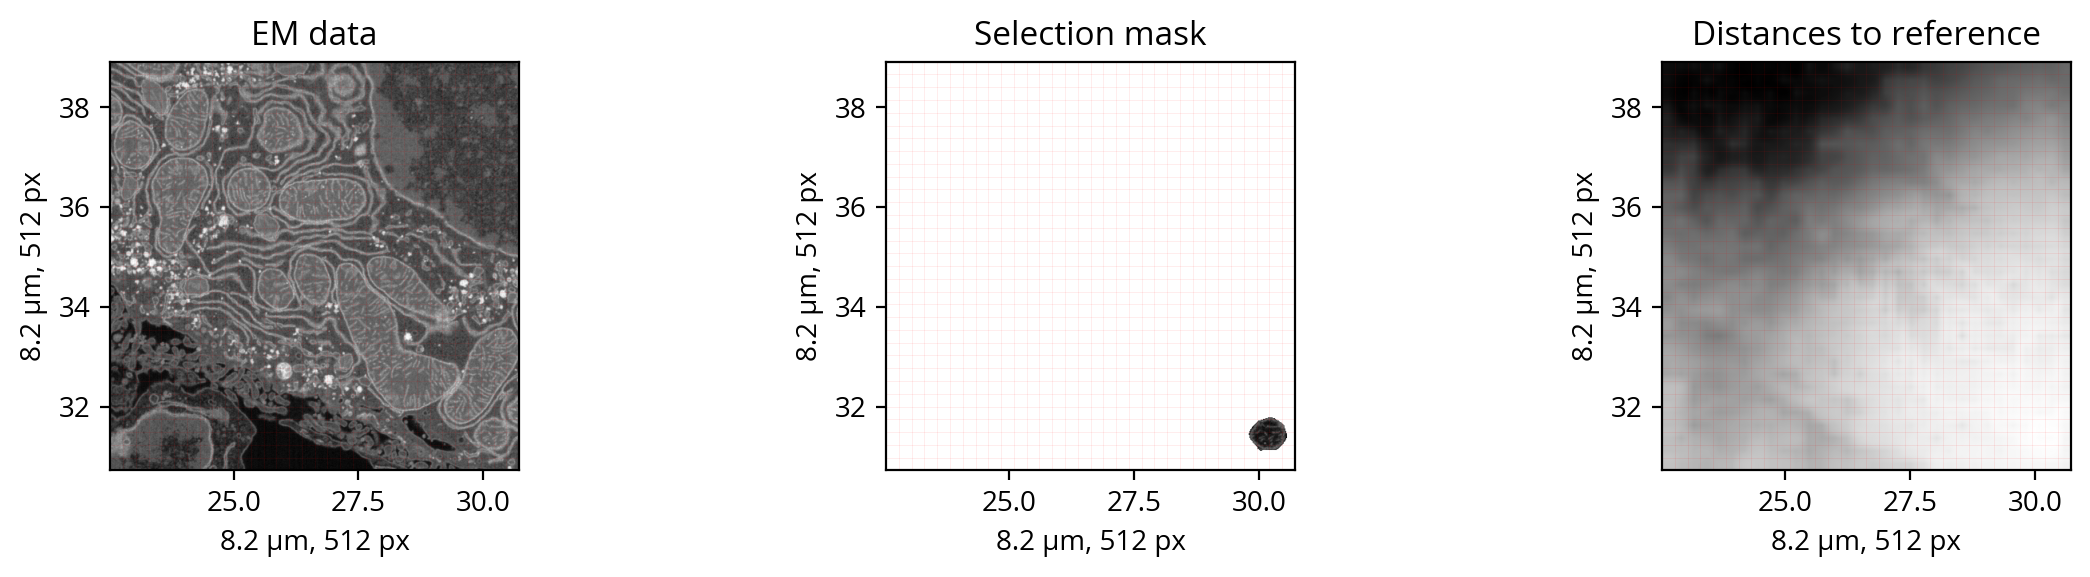

In [76]:
_ = slice_analyzer.select_mitochondria(mito_id)
_ = slice_analyzer.compute_distance_map()
slice_analyzer.plot()


In [94]:
from src.visualizer import create_cosine_distance_matrix, plot_distance_matrix
mito_vectors_arr = np.array(list(all_mito_vectors.values()))

dist_mat = create_cosine_distance_matrix(mito_vectors_arr)
dist_mat.shape

(158, 158)

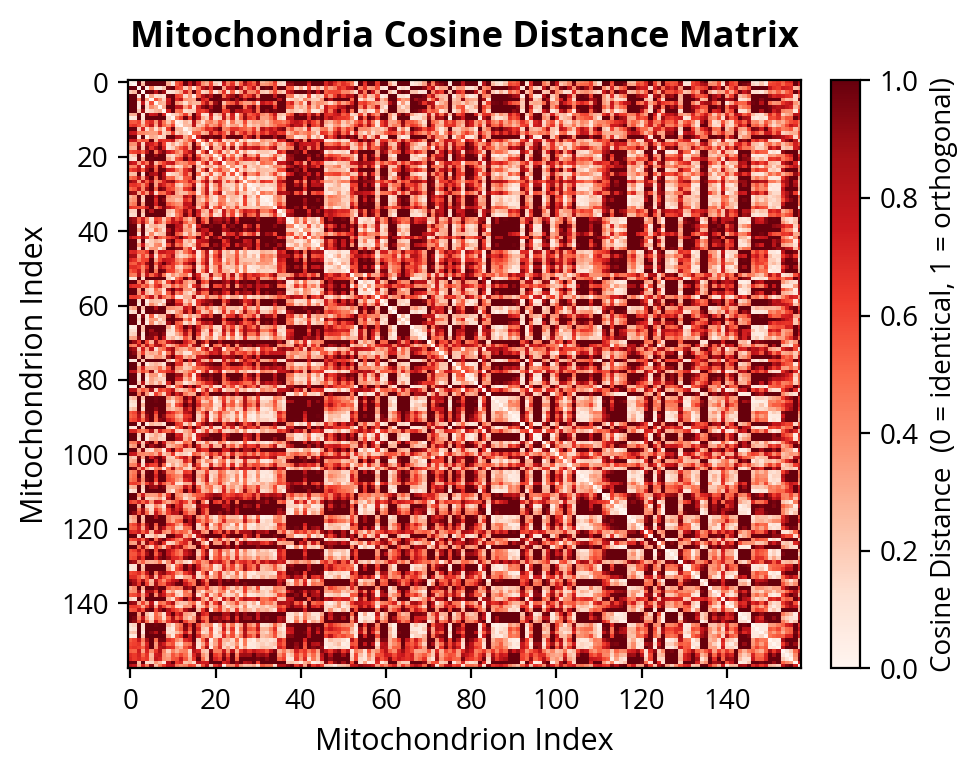

In [97]:
_ = plot_distance_matrix(dist_mat)


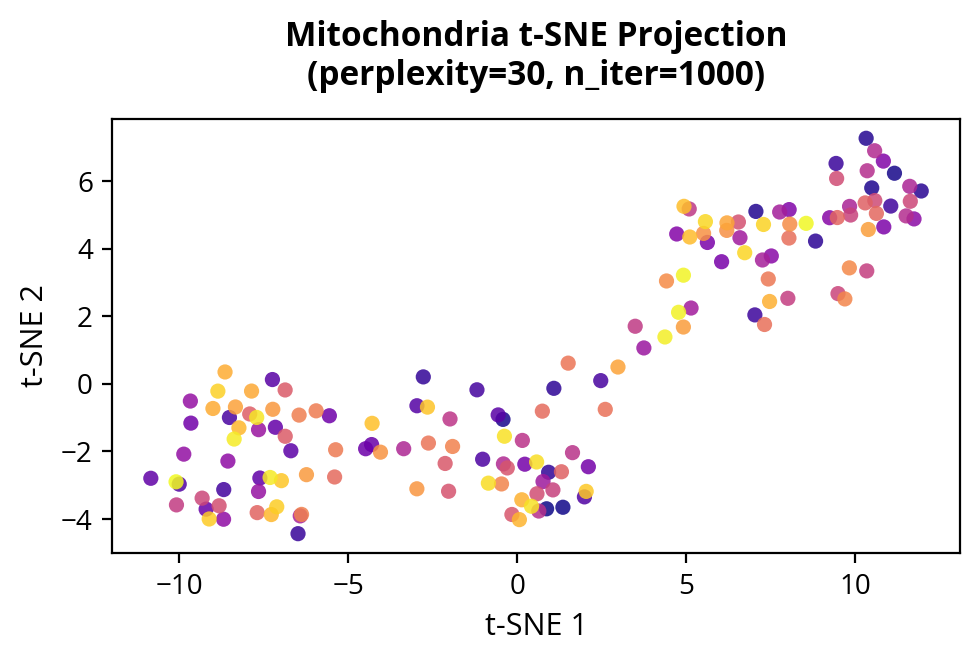

In [102]:
from src.visualizer import plot_tsne

_ = plot_tsne(mito_vectors_arr)